In [2]:
!zip -r fttq_figures.zip figures

  adding: figures/ (stored 0%)
  adding: figures/fig3_materials_blueprint.pdf (deflated 38%)
  adding: figures/fig4_scaling_eps.pdf (deflated 31%)
  adding: figures/fig2_gap_barrier.pdf (deflated 43%)
  adding: figures/fig1_qubit_concept.pdf (deflated 34%)
  adding: figures/fig4_scaling_B.pdf (deflated 36%)


In [1]:
# figures_pipeline.ipynb
# Colab-ready pipeline for generating all figures (1–4)

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import os

# Ensure output directory
os.makedirs("figures", exist_ok=True)

# ----------------------
# Figure 1: Conceptual Qubit
# ----------------------
def make_fig1():
    fig, ax = plt.subplots(figsize=(5,5))

    # Excitons
    exciton1 = plt.Circle((0.3, 0.5), 0.05, color="dodgerblue", ec="black", lw=1.2)
    exciton2 = plt.Circle((0.7, 0.5), 0.05, color="dodgerblue", ec="black", lw=1.2)
    ax.add_patch(exciton1)
    ax.add_patch(exciton2)

    # Braiding path
    braid_path = patches.Arc((0.5,0.5), 0.6, 0.6, theta1=30, theta2=330,
                             linestyle="--", color="darkorange", lw=2)
    ax.add_patch(braid_path)
    ax.annotate("", xy=(0.32,0.78), xytext=(0.68,0.78),
                arrowprops=dict(arrowstyle="->", color="darkorange", lw=2))

    # Poisoning
    ax.annotate(u"\u26A1", (0.5, 0.3), fontsize=22, color="crimson", ha="center")
    ax.text(0.52, 0.27, "Poisoning", fontsize=9, color="crimson", ha="center")

    # Labels
    ax.text(0.3, 0.45, "Exciton A", fontsize=10, ha="center", va="top")
    ax.text(0.7, 0.45, "Exciton B", fontsize=10, ha="center", va="top")

    ax.set_xlim(0,1); ax.set_ylim(0,1); ax.set_aspect("equal"); ax.axis("off")
    plt.tight_layout(); plt.savefig("figures/fig1_qubit_concept.pdf"); plt.close()

# ----------------------
# Figure 2: Energy Gap Barrier
# ----------------------
def make_fig2():
    fig, ax = plt.subplots(figsize=(5,4))

    # Levels
    ax.hlines(0, 0, 1, colors="black", linewidth=2)
    ax.text(-0.05, 0, "Ground State", va="center", ha="right", fontsize=9)
    ax.hlines(1, 0, 1, colors="black", linewidth=2)
    ax.text(-0.05, 1, "Excited State", va="center", ha="right", fontsize=9)

    # Δ_topo arrow
    ax.annotate("", xy=(0.5,1), xytext=(0.5,0),
                arrowprops=dict(arrowstyle="<->", lw=1.5, color="dodgerblue"))
    ax.text(0.55, 0.5, r"$\Delta_{\mathrm{topo}}$", fontsize=11, color="dodgerblue", va="center")

    # Thermal energy
    ax.arrow(0.2, 0, 0, 0.3, head_width=0.05, head_length=0.05, fc="red", ec="red")
    ax.text(0.25, 0.15, r"$k_B T$", color="red", fontsize=9)

    # High-energy event
    ax.arrow(0.8, 0, 0, 1.2, head_width=0.05, head_length=0.05, fc="crimson", ec="crimson")
    ax.text(0.85, 0.6, r"$E_{\mathrm{event}}$", color="crimson", fontsize=9, rotation=90, va="center")

    ax.set_xlim(0,1); ax.set_ylim(-0.2,1.4); ax.axis("off")
    plt.tight_layout(); plt.savefig("figures/fig2_gap_barrier.pdf"); plt.close()

# ----------------------
# Figure 3: Materials Blueprint
# ----------------------
def make_fig3():
    fig, ax = plt.subplots(figsize=(5,5))

    # TMD layers
    rect1 = patches.Rectangle((0.1,0.3), 0.8, 0.1, angle=5,
                              linewidth=1.2, edgecolor="black", facecolor="lightblue", alpha=0.7)
    rect2 = patches.Rectangle((0.1,0.5), 0.8, 0.1, angle=-5,
                              linewidth=1.2, edgecolor="black", facecolor="lightgreen", alpha=0.7)
    ax.add_patch(rect1); ax.add_patch(rect2)

    # Moiré dots
    for x in np.linspace(0.15,0.85,5):
        for y in [0.33, 0.53]:
            ax.plot(x,y,"o",color="gray",markersize=3,alpha=0.7)

    # Magnetic field
    ax.annotate(r"$B$", xy=(0.95,0.7), xytext=(0.95,0.9),
                arrowprops=dict(arrowstyle="->", lw=1.5, color="navy"), fontsize=11, color="navy")

    # Strain arrows
    ax.annotate("", xy=(0.1,0.28), xytext=(0.0,0.28),
                arrowprops=dict(arrowstyle="<->", lw=1.5, color="darkorange"))
    ax.text(0.05,0.25,"Strain", color="darkorange", fontsize=9, ha="center")

    # Labels
    ax.text(0.5,0.62,"Twisted TMD Heterostructures", ha="center", fontsize=10)
    ax.text(0.5,0.18,"Encapsulation (hBN, low-$\\epsilon$)", ha="center", fontsize=9, color="dimgray")

    ax.set_xlim(0,1); ax.set_ylim(0,1); ax.axis("off"); ax.set_aspect("equal")
    plt.tight_layout(); plt.savefig("figures/fig3_materials_blueprint.pdf"); plt.close()

# ----------------------
# Figure 4: Scaling Laws
# ----------------------
def make_fig4():
    kB_T = 0.001
    B = np.linspace(5, 30, 200)
    eps = np.linspace(2, 15, 200)
    Delta_B = np.sqrt(B) * 0.01
    Delta_eps = (1/eps) * 0.05

    # Δ vs B
    plt.figure(figsize=(6,4))
    plt.plot(B, Delta_B, label=r'$\Delta_{\mathrm{topo}} \propto \sqrt{B}$')
    plt.axhline(kB_T, color='red', linestyle='--', label=r'$k_B T$ (10 mK)')
    plt.fill_between(B, kB_T, Delta_B, where=Delta_B>kB_T,
                     color='green', alpha=0.2, label='Operational regime')
    plt.xlabel(r'Magnetic Field $B$ (Tesla)')
    plt.ylabel(r'$\Delta_{\mathrm{topo}}$ (arb. units)')
    plt.legend(); plt.tight_layout()
    plt.savefig("figures/fig4_scaling_B.pdf"); plt.close()

    # Δ vs ε
    plt.figure(figsize=(6,4))
    plt.plot(eps, Delta_eps, label=r'$\Delta_{\mathrm{topo}} \propto 1/\epsilon$')
    plt.axhline(kB_T, color='red', linestyle='--', label=r'$k_B T$ (10 mK)')
    plt.fill_between(eps, kB_T, Delta_eps, where=Delta_eps>kB_T,
                     color='blue', alpha=0.2, label='Operational regime')
    plt.xlabel(r'Dielectric Constant $\epsilon$')
    plt.ylabel(r'$\Delta_{\mathrm{topo}}$ (arb. units)')
    plt.legend(); plt.tight_layout()
    plt.savefig("figures/fig4_scaling_eps.pdf"); plt.close()

# ----------------------
# Run All
# ----------------------
make_fig1()
make_fig2()
make_fig3()
make_fig4()

print("✅ All figures generated in ./figures/")


✅ All figures generated in ./figures/


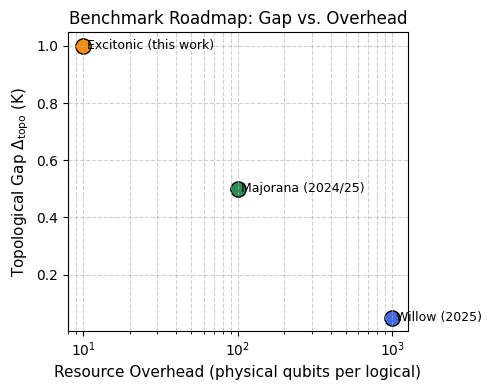

In [3]:
# --- Figure: Benchmark Gap vs. Overhead ---
import matplotlib.pyplot as plt
import os

os.makedirs("figures", exist_ok=True)

fig, ax = plt.subplots(figsize=(5,4))

# Data: (Overhead in log-scale, Gap in K)
platforms = ["Willow (2025)", "Majorana (2024/25)", "Excitonic (this work)"]
overhead = [1e3, 100, 10]   # approximate resource overhead scaling
gap = [0.05, 0.5, 1.0]      # in Kelvin (illustrative)

colors = ["royalblue", "seagreen", "darkorange"]

for i, (x, y, label) in enumerate(zip(overhead, gap, platforms)):
    ax.scatter(x, y, s=120, color=colors[i], label=label, edgecolor="black")
    ax.text(x*1.05, y, label, fontsize=9, va="center")

ax.set_xscale("log")
ax.set_xlabel("Resource Overhead (physical qubits per logical)", fontsize=11)
ax.set_ylabel(r"Topological Gap $\Delta_{\mathrm{topo}}$ (K)", fontsize=11)
ax.set_title("Benchmark Roadmap: Gap vs. Overhead", fontsize=12)

ax.grid(True, which="both", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.savefig("figures/fig_benchmark_gap_vs_overhead.pdf")
plt.show()


In [4]:
# Generate numerical estimates for Δ_topo prefactors and save a CSV for supplementary materials.
import numpy as np
import pandas as pd
import os
from caas_jupyter_tools import display_dataframe_to_user

# Constants
meV_per_K = 1.0/11.6045  # meV per Kelvin
K_per_meV = 11.6045
# Coulomb energy prefactor: Ec ≈ (56.11 meV) * sqrt(B[T]) / ε
Ec_prefactor_meV = 56.11

# Parameter grids
B_list = [10, 15, 20, 30, 45]  # Tesla
epsilon_list = [3.5, 4.0, 6.0, 10.0]  # effective dielectric environments
kappa_list = [0.05, 0.10, 0.15]  # fraction of Coulomb scale contributing to Δ_topo

rows = []
for B in B_list:
    sqrtB = np.sqrt(B)
    for eps in epsilon_list:
        Ec_meV = Ec_prefactor_meV * sqrtB / eps  # Coulomb scale in meV
        for kappa in kappa_list:
            Delta_meV = kappa * Ec_meV
            Delta_K = Delta_meV * K_per_meV
            rows.append({
                "B_T": B,
                "epsilon_eff": eps,
                "kappa": kappa,
                "Ec_meV": round(Ec_meV, 3),
                "Delta_topo_meV": round(Delta_meV, 3),
                "Delta_topo_K": round(Delta_K, 2)
            })

df = pd.DataFrame(rows)

# Create a pivoted quick-look table for a typical encapsulation (epsilon=4.0), vary B and kappa
df_eps4 = df[df["epsilon_eff"] == 4.0].pivot_table(index="B_T", columns="kappa", values="Delta_topo_K")
df_eps4 = df_eps4.rename(columns=lambda k: f"Δ_topo (κ={k:.2f}) [K]")

# Ensure directories and save CSV
os.makedirs("/mnt/data/supplementary", exist_ok=True)
csv_path = "/mnt/data/supplementary/delta_topo_estimates.csv"
df.to_csv(csv_path, index=False)

# Display concise table to user
display_dataframe_to_user("Δ_topo Estimates (epsilon=4.0, in Kelvin)", df_eps4.reset_index())

csv_path


ModuleNotFoundError: No module named 'caas_jupyter_tools'

In [5]:
# Load the CSV we generated earlier and prepare a LaTeX tabular environment for Supplementary Table S1
df_loaded = pd.read_csv("delta_topo_estimates.csv")

# Select a representative subset for readability in supplementary (say, epsilon=4.0)
df_subset = df_loaded[df_loaded["epsilon_eff"] == 4.0].copy()

# Pivot to show B vs κ with values in Kelvin
table = df_subset.pivot_table(index="B_T", columns="kappa", values="Delta_topo_K")
table = table.rename(columns=lambda k: f"κ={k:.2f}")

# Generate LaTeX tabular code
latex_table = table.to_latex(float_format="%.1f", caption="Supplementary Table S1. Estimated topological gap $\\Delta_{\\text{topo}}$ in Kelvin for representative dielectric environment ($\\epsilon=4.0$). Values computed using $\\Delta_{\\text{topo}} \\approx \\kappa e^2/(\\epsilon \\ell_B)$ with scaling factor $\\kappa \\in [0.05,0.15]$.",
                             label="tab:delta_topo_estimates", bold_rows=True)

latex_table[:1000]  # preview first chunk of LaTeX code


'\\begin{table}\n\\caption{Supplementary Table S1. Estimated topological gap $\\Delta_{\\text{topo}}$ in Kelvin for representative dielectric environment ($\\epsilon=4.0$). Values computed using $\\Delta_{\\text{topo}} \\approx \\kappa e^2/(\\epsilon \\ell_B)$ with scaling factor $\\kappa \\in [0.05,0.15]$.}\n\\label{tab:delta_topo_estimates}\n\\begin{tabular}{lrrr}\n\\toprule\nkappa & κ=0.05 & κ=0.10 & κ=0.15 \\\\\nB_T &  &  &  \\\\\n\\midrule\n\\textbf{10} & 25.7 & 51.5 & 77.2 \\\\\n\\textbf{15} & 31.5 & 63.0 & 94.6 \\\\\n\\textbf{20} & 36.4 & 72.8 & 109.2 \\\\\n\\textbf{30} & 44.6 & 89.2 & 133.7 \\\\\n\\textbf{45} & 54.6 & 109.2 & 163.8 \\\\\n\\bottomrule\n\\end{tabular}\n\\end{table}\n'